#1. Load Dataset

In [1]:
!pip install dgeb datasets -q
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import average_precision_score
from datasets import load_dataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 32.7 MB/s eta 0:00:00


In [2]:
# Dataset Link: https://huggingface.co/tattabio/datasets?p=0
ecoli  = load_dataset("tattabio/ecoli_operonic_pair")
cyano  = load_dataset("tattabio/cyano_operonic_pair")
vibrio = load_dataset("tattabio/vibrio_operonic_pair")

print("E. coli columns:", ecoli["train"].features)
print("Cyano columns:",   cyano["train"].features)
print("Vibrio columns:",  vibrio["train"].features)

README.md:   0%|          | 0.00/345 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.41M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4315 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/342 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/836k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2611 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/344 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/910k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2574 [00:00<?, ? examples/s]

E. coli columns: {'Entry': Value('string'), 'Sequence': Value('string'), 'Label': Value('int64')}
Cyano columns: {'Entry': Value('string'), 'Sequence': Value('string'), 'Label': Value('int64')}
Vibrio columns: {'Entry': Value('string'), 'Sequence': Value('string'), 'Label': Value('int64')}


#2. Build Gene Pairs

In [3]:
def build_pairs(dataset_split):
    seqs   = dataset_split["Sequence"]
    labels = dataset_split["Label"]
    seq_a, seq_b, pair_labels = [], [], []
    for i in range(len(seqs) - 1):
        seq_a.append(seqs[i])
        seq_b.append(seqs[i + 1])
        pair_labels.append(labels[i])
    return seq_a, seq_b, np.array(pair_labels)

seq_a_ec, seq_b_ec, labels_ec = build_pairs(ecoli["train"])
seq_a_cy, seq_b_cy, labels_cy = build_pairs(cyano["train"])
seq_a_vi, seq_b_vi, labels_vi = build_pairs(vibrio["train"])

print(f"E. coli pairs: {len(labels_ec):,}, positive rate: {labels_ec.mean():.1%}")
print(f"Cyano pairs:   {len(labels_cy):,}, positive rate: {labels_cy.mean():.1%}")
print(f"Vibrio pairs:  {len(labels_vi):,}, positive rate: {labels_vi.mean():.1%}")

E. coli pairs: 4,314, positive rate: 40.5%
Cyano pairs:   2,610, positive rate: 28.2%
Vibrio pairs:  2,573, positive rate: 34.6%


#3. One-Hot Encoding + Train/Test Split

In [4]:
# One-Hot Encoding
AA_ALPHABET = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_IDX   = {aa: i for i, aa in enumerate(AA_ALPHABET)}
N_AA        = len(AA_ALPHABET)   # 20
L_MAX       = 749                # 95th percentile across all three datasets
ONE_HOT_DIM = L_MAX * N_AA      # 14,980 per gene

def one_hot_encode(seq, l_max=L_MAX):
    """Encode a single amino acid sequence as a flattened one-hot vector."""
    seq = seq.upper()[:l_max]          # truncate
    mat = np.zeros((l_max, N_AA), dtype=np.float32)
    for i, aa in enumerate(seq):
        if aa in AA_TO_IDX:
            mat[i, AA_TO_IDX[aa]] = 1.0
    return mat.flatten()               # (14,980,)

def encode_pairs_ohe(seq_a_list, seq_b_list, label=""):
    """Encode gene pairs as [flat_A || flat_B] -> X in R^29960."""
    print(f"Encoding {label} sequences...")
    X = []
    for a, b in zip(seq_a_list, seq_b_list):
        X.append(np.concatenate([one_hot_encode(a), one_hot_encode(b)]))
    X = np.array(X, dtype=np.float32)
    print(f"Done. Shape: {X.shape}")
    return X

X_ec = encode_pairs_ohe(seq_a_ec, seq_b_ec, "E. coli")
X_cy = encode_pairs_ohe(seq_a_cy, seq_b_cy, "Cyano")
X_vi = encode_pairs_ohe(seq_a_vi, seq_b_vi, "Vibrio")

Encoding E. coli sequences...
Done. Shape: (4314, 29960)
Encoding Cyano sequences...
Done. Shape: (2610, 29960)
Encoding Vibrio sequences...
Done. Shape: (2573, 29960)


In [5]:
# Stratified train/test split (80/20)
X_ec_train, X_ec_test, y_ec_train, y_ec_test = train_test_split(
    X_ec, labels_ec, test_size=0.2, stratify=labels_ec, random_state=42
)
X_cy_train, X_cy_test, y_cy_train, y_cy_test = train_test_split(
    X_cy, labels_cy, test_size=0.2, stratify=labels_cy, random_state=42
)
X_vi_train, X_vi_test, y_vi_train, y_vi_test = train_test_split(
    X_vi, labels_vi, test_size=0.2, stratify=labels_vi, random_state=42
)

print(f"E. coli  — train: {X_ec_train.shape[0]:,}  test: {X_ec_test.shape[0]:,}  dims: {X_ec_train.shape[1]:,}")
print(f"Cyano    — train: {X_cy_train.shape[0]:,}  test: {X_cy_test.shape[0]:,}  dims: {X_cy_train.shape[1]:,}")
print(f"Vibrio   — train: {X_vi_train.shape[0]:,}  test: {X_vi_test.shape[0]:,}  dims: {X_vi_train.shape[1]:,}")

E. coli  — train: 3,451  test: 863  dims: 29,960
Cyano    — train: 2,088  test: 522  dims: 29,960
Vibrio   — train: 2,058  test: 515  dims: 29,960


#4. Complement Naive Bayes (CNB) — Hyperparameter Search

In [6]:
from sklearn.model_selection import StratifiedKFold

alphas     = [0.01, 0.1, 0.5, 1.0]
best_alpha = None
best_ap    = -1
cnb_scores = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("ComplementNB alpha search (5-fold CV on E. coli training set)")
print("-" * 50)
for alpha in alphas:
    model    = ComplementNB(alpha=alpha)
    cv_scores = cross_val_score(
        model, X_ec_train, y_ec_train,
        cv=skf, scoring="average_precision", n_jobs=-1
    )
    avg_ap = cv_scores.mean()
    cnb_scores.append(avg_ap)
    print(f"  alpha={alpha:<6}  CV AP={avg_ap:.4f}")
    if avg_ap > best_ap:
        best_ap    = avg_ap
        best_alpha = alpha

print()
print(f"Best alpha : {best_alpha}")
print(f"Best CV AP : {best_ap:.4f}")

ComplementNB alpha search (5-fold CV on E. coli training set)
--------------------------------------------------
  alpha=0.01    CV AP=0.4220
  alpha=0.1     CV AP=0.4215
  alpha=0.5     CV AP=0.4190
  alpha=1.0     CV AP=0.4164

Best alpha : 0.01
Best CV AP : 0.4220


#5. Logistic Regression — Hyperparameter Search

In [7]:
Cs       = [0.01, 0.1, 1.0, 10.0, 100.0]
best_C   = None
best_ap  = -1
lr_scores = []

print("Logistic Regression C search (5-fold CV on E. coli training set)")
print("-" * 50)
for C in Cs:
    model = LogisticRegression(
        C=C, penalty="l2", solver="lbfgs",
        max_iter=1000, class_weight="balanced", random_state=42
    )
    cv_scores = cross_val_score(
        model, X_ec_train, y_ec_train,
        cv=skf, scoring="average_precision", n_jobs=-1
    )
    avg_ap = cv_scores.mean()
    lr_scores.append(avg_ap)
    print(f"  C={C:<8}  CV AP={avg_ap:.4f}")
    if avg_ap > best_ap:
        best_ap = avg_ap
        best_C  = C

print()
print(f"Best C     : {best_C}")
print(f"Best CV AP : {best_ap:.4f}")

Logistic Regression C search (5-fold CV on E. coli training set)
--------------------------------------------------
  C=0.01      CV AP=0.4620
  C=0.1       CV AP=0.4553
  C=1.0       CV AP=0.4520
  C=10.0      CV AP=0.4483
  C=100.0     CV AP=0.4465

Best C     : 0.01
Best CV AP : 0.4620


#6. Hyperparameter Tuning Plots

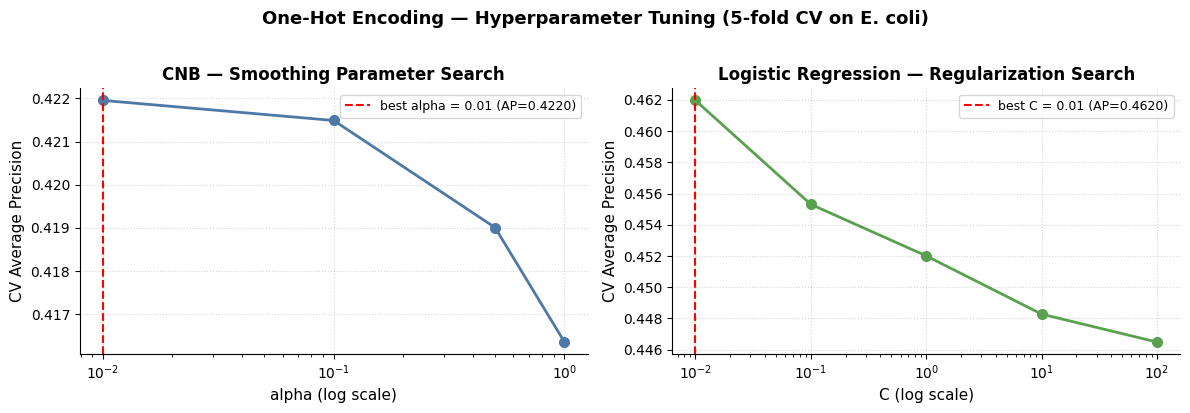

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# --- CNB ---
ax1.plot(alphas, cnb_scores, marker="o", color="#4E79A7", linewidth=2, markersize=7)
ax1.axvline(best_alpha, linestyle="--", color="red",
            label=f"best alpha = {best_alpha} (AP={max(cnb_scores):.4f})")
ax1.set_xscale("log")
ax1.set_xlabel("alpha (log scale)", fontsize=11)
ax1.set_ylabel("CV Average Precision", fontsize=11)
ax1.set_title("CNB — Smoothing Parameter Search", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(True, linestyle=":", alpha=0.5)
ax1.spines[["top", "right"]].set_visible(False)

# --- LR ---
ax2.plot(Cs, lr_scores, marker="o", color="#59A14F", linewidth=2, markersize=7)
ax2.axvline(best_C, linestyle="--", color="red",
            label=f"best C = {best_C} (AP={max(lr_scores):.4f})")
ax2.set_xscale("log")
ax2.set_xlabel("C (log scale)", fontsize=11)
ax2.set_ylabel("CV Average Precision", fontsize=11)
ax2.set_title("Logistic Regression — Regularization Search", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, linestyle=":", alpha=0.5)
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("One-Hot Encoding — Hyperparameter Tuning (5-fold CV on E. coli)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("ohe_hyperparameter_search.png", dpi=150, bbox_inches="tight")
plt.show()

#7. Training — Fit Best Models on All Organisms

In [9]:
def train_and_evaluate(model, datasets):
    """Fit model on each organism's train set and evaluate on its test set."""
    results = {}
    for name, X_train, y_train, X_test, y_test in datasets:
        model.fit(X_train, y_train)
        y_score = model.predict_proba(X_test)[:, 1]
        ap = average_precision_score(y_test, y_score)
        results[name] = round(ap, 4)
        print(f"  [{name}] AP = {ap:.4f}")
    return results

all_datasets = [
    ("E. coli", X_ec_train, y_ec_train, X_ec_test, y_ec_test),
    ("Cyano",   X_cy_train, y_cy_train, X_cy_test, y_cy_test),
    ("Vibrio",  X_vi_train, y_vi_train, X_vi_test, y_vi_test),
]

print("--- CNB + One-Hot ---")
cnb_model  = ComplementNB(alpha=best_alpha)
cnb_results = train_and_evaluate(cnb_model, all_datasets)

print("\n--- Logistic Regression + One-Hot ---")
lr_model   = LogisticRegression(
    C=best_C, penalty="l2", solver="lbfgs",
    max_iter=1000, class_weight="balanced", random_state=42
)
lr_results  = train_and_evaluate(lr_model, all_datasets)

--- CNB + One-Hot ---
  [E. coli] AP = 0.4523
  [Cyano] AP = 0.3075
  [Vibrio] AP = 0.3186

--- Logistic Regression + One-Hot ---
  [E. coli] AP = 0.4803
  [Cyano] AP = 0.3192
  [Vibrio] AP = 0.3333


#8. Results Table vs DGEB Baselines

In [10]:
dgeb_baselines = {
    "E. coli": {"ESM2-650M": 0.5727, "ESM3": 0.5774, "ProtTrans": 0.6180},
    "Cyano":   {"ESM2-650M": 0.3733, "ESM3": 0.3899, "ProtTrans": 0.4092},
    "Vibrio":  {"ESM2-650M": 0.4828, "ESM3": 0.4971, "ProtTrans": 0.5427},
}

rows = []
for dataset in ["E. coli", "Cyano", "Vibrio"]:
    rows.append({
        "Dataset":             dataset,
        "CNB + One-Hot":       cnb_results[dataset],
        "LR + One-Hot":        lr_results[dataset],
        "ESM2-650M†":          dgeb_baselines[dataset]["ESM2-650M"],
        "ESM3†":               dgeb_baselines[dataset]["ESM3"],
        "ProtTrans†":          dgeb_baselines[dataset]["ProtTrans"],
    })

results_df = pd.DataFrame(rows).set_index("Dataset")
print("Average Precision Comparison")
print("† Frozen embeddings from DGEB (West-Roberts et al., 2024)")
print()
print(results_df.to_string())

# avg row
results_df.loc["Average"] = results_df.mean()
print()
print("Row averages:")
print(results_df.loc["Average"].to_string())

Average Precision Comparison
† Frozen embeddings from DGEB (West-Roberts et al., 2024)

         CNB + One-Hot  LR + One-Hot  ESM2-650M†   ESM3†  ProtTrans†
Dataset                                                             
E. coli         0.4523        0.4803      0.5727  0.5774      0.6180
Cyano           0.3075        0.3192      0.3733  0.3899      0.4092
Vibrio          0.3186        0.3333      0.4828  0.4971      0.5427

Row averages:
CNB + One-Hot    0.359467
LR + One-Hot     0.377600
ESM2-650M†       0.476267
ESM3†            0.488133
ProtTrans†       0.523300


#9. OHE Results vs DGEB Baselines

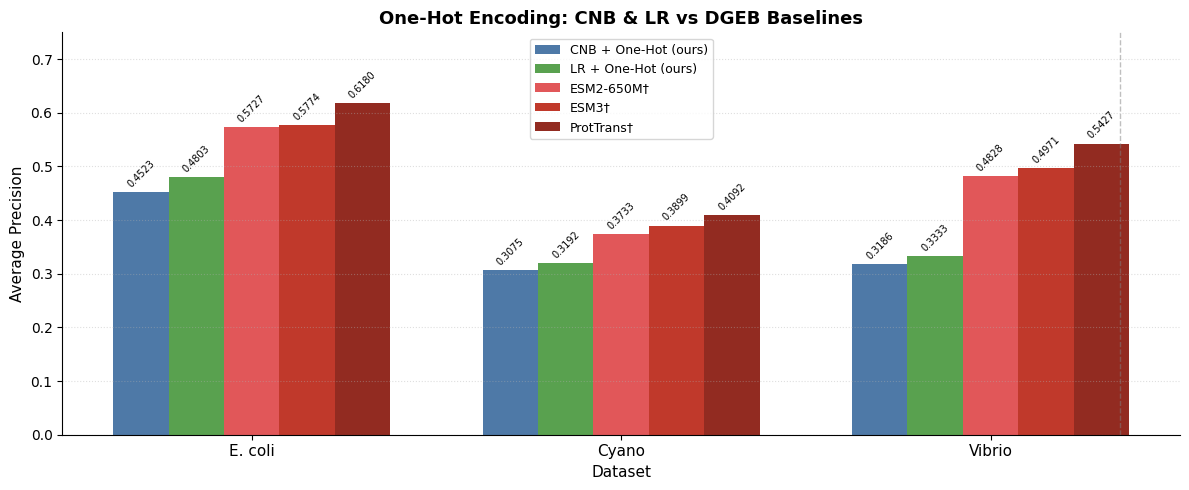

In [11]:
datasets = ["E. coli", "Cyano", "Vibrio"]

methods = {
    "CNB + One-Hot (ours)": [cnb_results[d] for d in datasets],
    "LR + One-Hot (ours)":  [lr_results[d]  for d in datasets],
    "ESM2-650M†":           [dgeb_baselines[d]["ESM2-650M"] for d in datasets],
    "ESM3†":                [dgeb_baselines[d]["ESM3"]      for d in datasets],
    "ProtTrans†":           [dgeb_baselines[d]["ProtTrans"]  for d in datasets],
}

colors = ["#4E79A7", "#59A14F", "#E15759", "#C0392B", "#922B21"]
x      = np.arange(len(datasets))
width  = 0.15

fig, ax = plt.subplots(figsize=(12, 5))
for i, (method, scores) in enumerate(methods.items()):
    bars = ax.bar(x + i * width, scores, width, label=method, color=colors[i])
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=7, rotation=45)

ax.axvline(x=len(datasets) - 0.5 + width, color="gray",
           linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Dataset", fontsize=11)
ax.set_ylabel("Average Precision", fontsize=11)
ax.set_title("One-Hot Encoding: CNB & LR vs DGEB Baselines",
             fontsize=13, fontweight="bold")
ax.set_xticks(x + width * 2)
ax.set_xticklabels(datasets, fontsize=11)
ax.set_ylim(0, 0.75)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig("ohe_vs_baselines.png", dpi=150, bbox_inches="tight")
plt.show()

#10. All Representations vs DGEB Baselines

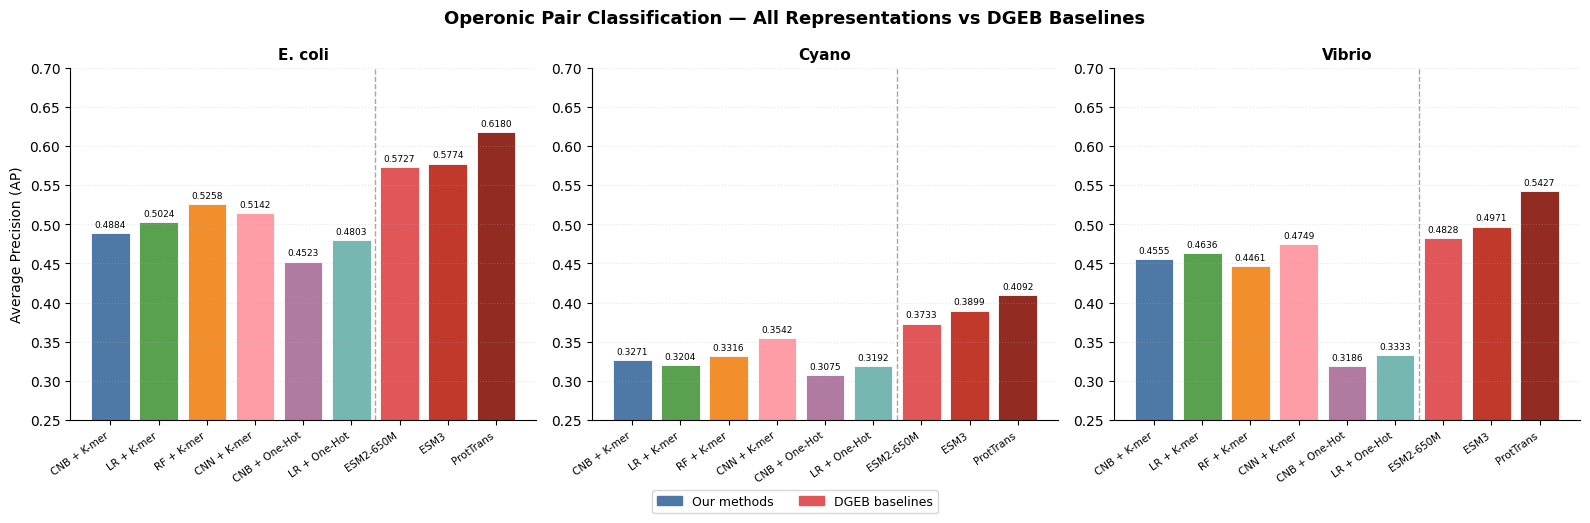

In [12]:
import matplotlib.patches as mpatches

datasets = ["E. coli", "Cyano", "Vibrio"]

our_methods = {
    "CNB + K-mer":   [0.4884, 0.3271, 0.4555],
    "LR + K-mer":    [0.5024, 0.3204, 0.4636],
    "RF + K-mer":    [0.5258, 0.3316, 0.4461],
    "CNN + K-mer":   [0.5142, 0.3542, 0.4749],
    "CNB + One-Hot": [cnb_results[d] for d in datasets],
    "LR + One-Hot":  [lr_results[d]  for d in datasets],
}

dgeb_methods = {
    "ESM2-650M": [0.5727, 0.3733, 0.4828],
    "ESM3":      [0.5774, 0.3899, 0.4971],
    "ProtTrans": [0.6180, 0.4092, 0.5427],
}

our_colors  = ["#4E79A7", "#59A14F", "#F28E2B", "#FF9DA7", "#B07AA1", "#76B7B2"]
dgeb_colors = ["#E15759", "#C0392B", "#922B21"]

all_methods = {**our_methods, **dgeb_methods}
all_colors  = our_colors + dgeb_colors

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("Operonic Pair Classification — All Representations vs DGEB Baselines",
             fontsize=13, fontweight="bold")

x      = np.arange(len(all_methods))
labels = list(all_methods.keys())

for ax, dataset, ds_idx in zip(axes, datasets, range(3)):
    scores = [v[ds_idx] for v in all_methods.values()]
    bars   = ax.bar(x, scores, color=all_colors, edgecolor="white", linewidth=0.6)

    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=6.5)

    ax.axvline(x=len(our_methods) - 0.5, color="gray",
               linestyle="--", linewidth=1, alpha=0.7)

    ax.set_title(dataset, fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=7.5)
    ax.set_ylim(0.25, 0.70)
    ax.set_ylabel("Average Precision (AP)" if ds_idx == 0 else "")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linestyle=":")

our_patch  = mpatches.Patch(color="#4E79A7", label="Our methods")
dgeb_patch = mpatches.Patch(color="#E15759", label="DGEB baselines")
fig.legend(handles=[our_patch, dgeb_patch], loc="lower center",
           ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("all_representations_vs_baselines.png", dpi=150, bbox_inches="tight")
plt.show()